In [5]:
# statistical tests using the data 
#   load the correponding dataset by un-commenting the corresponding line
#   normality tests
#   correlation and partial correlation analysis, for shape measures vs SARA, CAG, CCFS and INAS

In [6]:
#!pip install pingouin

In [7]:
import numpy as np
import pandas as pd

from scipy.stats import shapiro   # for normality test
from scipy.stats import pearsonr, spearmanr  # for correlation analysis (Pearson-normal, Spearman-non-normal)
import statsmodels.formula.api as smf # for formula form of Ancova, ols etc
import statsmodels.api as sm      # for Ancova, non-formular form
import statsmodels.formula.api as smf       # for linear mixed-effects models (LMM)
import pingouin as pg             # for partial correlation

import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
curRoot = 'C'  # 'C' or 'D'S

In [9]:
# Load shape measures, SELECTED, ctl_1_max
curRegion = 'CSSyl'  # !!! modify !!!
typeDist = 'max'     # !!! modify !!!
curSCA = 1           # !!! modify !!!

# for CSpreCS analysis ONLY
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca1_time1_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca1_time1_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca2_time1_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca2_time1_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca3_time1_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca3_time1_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca7_time1_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca7_time1_max.csv'

#file_path_ctl_1_max = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_max.csv'

# Time 1 and 2 separated, from combined set
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time2_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time2_max.csv'

# Time 1 and 2 combined, from combined set
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_and_2_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_and_2_max.csv'

# Original, time1 only
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca2_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca2_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca3_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca3_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca7_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca7_min.csv'

# relabeled, time1 only
#curPath = rf'D:\B_projWIP\proj_ataxia\RELABEL\relabel_time1_ctl_sca{curSCA}\{curRegion}\combined_time1_{typeDist}_ctl_sca{curSCA}.csv'
# relabeled, time2 only
#curPath = rf'D:\B_projWIP\proj_ataxia\RELABEL\relabel_time2_ctl_sca{curSCA}\{curRegion}\combined_time2_{typeDist}_ctl_sca{curSCA}.csv'
# relabeled, time1_2 
#curPath = rf'D:\B_projWIP\proj_ataxia\RELABEL\relabel_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_{typeDist}_ctl_sca{curSCA}.csv'
# relabeled, REDO, time1_2
curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_{typeDist}_ctl_sca{curSCA}.csv'
# relabeled, REDO, time1
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_ctl_sca{curSCA}\{curRegion}\combined_time1_{typeDist}_ctl_sca{curSCA}.csv'


# ORI, redo for verification
#curPath = rf'D:\B_projWIP\proj_ataxia\ORI\ORI_time1_ctl_sca{curSCA}\{curRegion}\combined_time1_{typeDist}_ctl_sca{curSCA}.csv'


In [32]:
combined = pd.read_csv(curPath)

#############  Need to specify: ONLY for time1 and 2 together  #############
#combined_time1 = combined[combined['Time_point']==1]
#combined_time2 = combined[combined['Time_point']!=1] # BIOSCA==2, CERMOI==3
#combined = combined_time1                      ########    CHANGE    ########

combined.index = combined['subjName']

# for correlation analysis
combined_L = combined[combined.index.str.startswith('L')]
combined_R = combined[combined.index.str.startswith('flip')]
combined_only_SCA = combined[combined['SCA'] == curSCA]

combined_CAG = combined.dropna(subset=['CAG'])
combined_CAG_only_SCA = combined_CAG[combined_CAG['SCA'] == curSCA]

combined_CCFS = combined.dropna(subset=['CCFS'])
combined_CCFS_only_SCA = combined_CCFS[combined_CCFS['SCA'] == curSCA]

combined_INAS = combined.dropna(subset=['INAS'])
combined_INAS_only_SCA = combined_INAS[combined_INAS['SCA'] == curSCA]

In [38]:
# Centering values
def centering_values(df):
    df.loc[:,'CAG_centered'] = df['CAG'] - df['CAG'].mean()
    df.loc[:,'SARA_centered'] = df['SARA'] - df['SARA'].mean()
    df.loc[:,'CCFS_centered'] = df['CCFS'] - df['CCFS'].mean()
    df.loc[:,'INAS_centered'] = df['INAS'] - df['INAS'].mean()    
    df.loc[:,'Age_onset_centered'] = df['Age_onset'] - df['Age_onset'].mean()
    df.loc[:,'Age_centered'] = df['Age'] - df['Age'].mean()
    df.loc[:,'iso1_centered'] = df['iso1'] - df['iso1'].mean()   
    df.loc[:,'iso2_centered'] = df['iso2'] - df['iso2'].mean()       
    df.loc[:,'iso3_centered'] = df['iso3'] - df['iso3'].mean()   
    df.loc[:,'UMAP1_U1_centered'] = df['UMAP1_U1'] - df['UMAP1_U1'].mean()   
    df.loc[:,'UMAP1_U2_centered'] = df['UMAP1_U2'] - df['UMAP1_U2'].mean() 
    df.loc[:,'UMAP1_U3_centered'] = df['UMAP1_U3'] - df['UMAP1_U3'].mean() 
    df.loc[:,'UMAP2_U3_centered'] = df['UMAP2_U3'] - df['UMAP2_U3'].mean() 
    df.loc[:,'UMAP1_U4_centered'] = df['UMAP1_U4'] - df['UMAP1_U4'].mean() 
    df.loc[:,'UMAP2_U4_centered'] = df['UMAP2_U4'] - df['UMAP2_U4'].mean() 
    df.loc[:,'iso1_asy_centered'] = df['iso1_asy'] - df['iso1_asy'].mean()   
    df.loc[:,'iso2_asy_centered'] = df['iso2_asy'] - df['iso2_asy'].mean()       
    df.loc[:,'iso3_asy_centered'] = df['iso3_asy'] - df['iso3_asy'].mean()      
    return df

combined_CAG_only_SCA_centered =  centering_values(combined_CAG_only_SCA)


In [11]:
##############################  Verifications  ###############################

In [12]:
print(len(combined_CAG))
print(len(combined_CAG_only_SCA))

84
62


In [13]:
print(combined_only_SCA.columns)
print(len(combined_only_SCA))

Index(['subjName', 'label', 'surface_talairach', 'surface_native',
       'maxdepth_talairach', 'maxdepth_native', 'meandepth_talairach',
       'meandepth_native', 'hull_junction_length_talairach',
       'hull_junction_length_native', 'GM_thickness', 'opening',
       'Randomization', 'SCA', 'CAG', 'Sex', 'Age', 'SARA', 'INAS',
       'Time_point', 'CodeICM', 'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2',
       'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4', 'Age_onset',
       'Group_ctl_pre_pat', 'Handedness', 'CCFS', 'Disease_duration',
       'allele1', 'allele2', 'side', 'SCA_side', 'dominantSide',
       'SCA_dominantSide', 'iso1_asy', 'iso2_asy', 'iso3_asy', 'UMAP1_U1_asy',
       'UMAP1_U2_asy', 'UMAP1_U3_asy', 'UMAP2_U3_asy', 'UMAP1_U4_asy',
       'UMAP2_U4_asy', 'surface_talairach_asy', 'surface_native_asy',
       'maxdepth_talairach_asy', 'maxdepth_native_asy',
       'meandepth_talairach_asy', 'meandepth_native_asy',
       'hull_junction_length_talairach_asy', 'hull_

In [14]:
# Step 1: Check data types
print(combined['SCA'].dtype)
# Step 2: Convert all entries to strings (or integers, as needed)
combined['SCA'] = combined['SCA'].astype(str).str.strip()
# Step 3: Ensure all values are stripped of leading/trailing whitespace
combined['SCA'] = combined['SCA'].str.strip()
# Step 4: Recompute the value counts
sca_counts = combined['SCA'].value_counts()
# Print the cleaned summary
print(sca_counts)

int64
SCA
0    104
1     62
Name: count, dtype: int64


In [15]:
# Display the values of the specified column
#print("Values in the 'CAG' column:")
#print(combined['CAG'])

# Get a summary of statistics
summary_stats = combined['CAG'].describe()
print("\nSummary statistics for the 'CAG' column:")
print(summary_stats)


Summary statistics for the 'CAG' column:
count    84.000000
mean     38.571429
std      15.150876
min      10.000000
25%      22.000000
50%      42.000000
75%      47.000000
max      62.000000
Name: CAG, dtype: float64


In [16]:
# Detect null values in a specific column
null_values = combined['CAG'].isnull()
#print(null_values)

# Filter rows where the specified column has null values
null_rows = combined[combined['CAG'].isnull()]
#print(null_rows['CAG'])

# Count the number of null values in a specific column
null_count = combined['CAG'].isnull().sum()
print(f"Number of null values in 'CAG': {null_count}")

# Count the number of null values in a specific column
null_count = combined_CAG['CAG'].isnull().sum()
print(f"Number of null values in 'combined_CAG': {null_count}")

Number of null values in 'CAG': 82
Number of null values in 'combined_CAG': 0


In [17]:
cer = combined[combined['CodeICM'] == 'CERMOI']
#print(cer['CAG'])
#print(combined.loc['L00030CA_V1']) # there are 4 subjects without CAG values

#is_null = combined.loc['L00030CA_V1', 'CAG'] is None or pd.isnull(combined.loc['L00030CA_V1', 'CAG'])
# Print the result
#print(is_null)


In [18]:
########################################  Stats  #############################################

In [19]:
#########################  Testing Normality  ##########################

In [20]:
measures = ['iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4','opening','maxdepth_talairach']

# Shapiro-Wilk test for normality, not normally distributed if p-val < 0.05
def run_shapiro_tests(df, measure_list):
    for measure in measure_list:
        if measure in df.columns:
            stat, p_value = shapiro(df[measure].dropna())  # dropna to avoid issues with NaN
            print(f'{measure} p-val: {p_value}')
        else:
            print(f"Warning: '{measure}' not found in DataFrame columns.")

# Run the function
print('Normality test stats for Control + SCA:')
run_shapiro_tests(combined, measures)
print()
print('Normality test stats for only SCA:')
run_shapiro_tests(combined_only_SCA, measures)

Normality test stats for Control + SCA:
iso1 p-val: 0.29079951384854036
iso2 p-val: 0.020540159062166847
iso3 p-val: 0.016863749717678175
UMAP1_U1 p-val: 0.0008037296414664206
UMAP1_U2 p-val: 0.0007196906290342857
UMAP1_U3 p-val: 3.1439647313704286e-07
UMAP2_U3 p-val: 2.2177122051707535e-06
UMAP1_U4 p-val: 0.008033057728214337
UMAP2_U4 p-val: 0.009545472449182626
opening p-val: 0.029856162779388674
maxdepth_talairach p-val: 0.04531277022439186

Normality test stats for only SCA:
iso1 p-val: 0.050723608882434934
iso2 p-val: 0.06285792455826053
iso3 p-val: 0.5570674177202833
UMAP1_U1 p-val: 0.03040037041677266
UMAP1_U2 p-val: 0.0015377191182252457
UMAP1_U3 p-val: 0.00037906977349161635
UMAP2_U3 p-val: 0.00015585299438330337
UMAP1_U4 p-val: 0.031516770498853215
UMAP2_U4 p-val: 0.0038824412710456832
opening p-val: 0.012753635081700741
maxdepth_talairach p-val: 0.02621285496772548


In [21]:
# Define the mappings for handedness and side, change from categorical to numerical for partial correlation stats
handedness_mapping = {'Droite': 1, 'Gauche': 2}
side_mapping = {'L': 1, 'R': 2}
centre_mapping = {'ATRIL': 1, 'BIOSCA': 2,'CERMOI':3}
    
# Make a copy of the DataFrame, to change Handedness and side from category to integer without warning
combined_only_SCA = combined_only_SCA.copy()
combined_CAG_only_SCA = combined_CAG_only_SCA.copy()
combined_CCFS_only_SCA = combined_CCFS_only_SCA.copy()
combined_INAS_only_SCA = combined_INAS_only_SCA.copy()
# Apply the mappings to the DataFrame
combined_only_SCA['Handedness'] = combined_only_SCA['Handedness'].replace(handedness_mapping)
combined_only_SCA['side'] = combined_only_SCA['side'].replace(side_mapping)
combined_only_SCA['CodeICM'] = combined_only_SCA['CodeICM'].replace(centre_mapping)
combined_CAG_only_SCA['Handedness'] = combined_CAG_only_SCA['Handedness'].replace(handedness_mapping)
combined_CAG_only_SCA['side'] = combined_CAG_only_SCA['side'].replace(side_mapping)
combined_CAG_only_SCA['CodeICM'] = combined_CAG_only_SCA['CodeICM'].replace(centre_mapping)
combined_CCFS_only_SCA['Handedness'] = combined_CCFS_only_SCA['Handedness'].replace(handedness_mapping)
combined_CCFS_only_SCA['side'] = combined_CCFS_only_SCA['side'].replace(side_mapping)
combined_CCFS_only_SCA['CodeICM'] = combined_CCFS_only_SCA['CodeICM'].replace(centre_mapping)
combined_INAS_only_SCA['Handedness'] = combined_INAS_only_SCA['Handedness'].replace(handedness_mapping)
combined_INAS_only_SCA['side'] = combined_INAS_only_SCA['side'].replace(side_mapping)
combined_INAS_only_SCA['CodeICM'] = combined_INAS_only_SCA['CodeICM'].replace(centre_mapping)

C:\Users\joyca\AppData\Local\Temp\ipykernel_36588\778700646.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_only_SCA['Handedness'] = combined_only_SCA['Handedness'].replace(handedness_mapping)
C:\Users\joyca\AppData\Local\Temp\ipykernel_36588\778700646.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_only_SCA['side'] = combined_only_SCA['side'].replace(side_mapping)
C:\Users\joyca\AppData\Local\Temp\ipykernel_36588\778700646.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will b

In [22]:
##################   verification before running linear regression   ###################
# Check the standard deviation of relevant variables
# when the value is close of equal to 0, the little variation causes the covariate matrix to be degenarate
# warning message will occur running the linear regression below
print(combined_only_SCA['CodeICM'].std())
print(combined_only_SCA['Sex'].std())

0.0
0.497481760000887


In [23]:
# Use linear regression with Pearson's coef between residuals, handles partail correlation, Gaussian or non-Gaussian
# Can use Spearman's partial correlation for non-linear relationships, not implemented yet.

#from scipy.stats import pearsonr, spearmanr

# Define lists of measures and test columns
curMeasures = ['iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4']
curMeasures_long = [
    'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4'
    'surface_talairach','surface_native','maxdepth_talairach','maxdepth_native','meandepth_talairach',
    'meandepth_native','hull_junction_length_talairach', 'hull_junction_length_native', 'GM_thickness', 'opening'
#    'iso1_asy', 'iso2_asy', 'iso3_asy', 'UMAP1_U1_asy', 'UMAP1_U2_asy', 'UMAP1_U3_asy', 'UMAP2_U3_asy', 'UMAP1_U4_asy', 'UMAP2_U4_asy'
#    'surface_talairach_asy', 'surface_native_asy', 'maxdepth_talairach_asy','maxdepth_native_asy', 'meandepth_talairach_asy',
#    'meandepth_native_asy', 'hull_junction_length_talairach_asy', 'hull_junction_length_native_asy', 
#    'GM_thickness_asy', 'opening_asy'
]
curTestCols = ['SARA','CAG','CCFS','INAS'] 

# Compute Pearson or Spearman correlations
def compute_correlations(df, measures, test_col):
    #covariates = ['Age','Disease_duration','Age_onset','side','Sex','CodeICM']   # add CodeICM only when more than one centre!
    #covariates = ['Age','Disease_duration','Age_onset','side','Sex']            
    #covariates = ['Age','side','Sex','CodeICM','Disease_duration','Age_onset']  # if SCA2, SCA7, add CodeICm
    #covariates = ['Age','side','Sex','Disease_duration','Age_onset']  # if SCA1, SCA3, not adding CodeICM#
    covariates = ['side','Sex','Age_onset']  # if SCA1, SCA3       
    #covariates = ['Age','side','Sex']  # if SCA1, SCA3      
    #covariates = ['Age','side','Age_onset']  # if SCA1, SCA3        
    for measure in measures:
        if measure in df.columns and test_col in df.columns:
            # Compute Pearson's and Spearman's correlation
            pearson_corr, pearson_p_value = pearsonr(df[measure], df[test_col])
            spearman_corr, spearman_p_value = spearmanr(df[measure], df[test_col])

            partial_corr_result_pearson = pg.partial_corr(data=df, 
                                      x=measure, 
                                      y=test_col, 
                                      covar=covariates, 
                                      method='pearson')
            partial_corr_result_spearman = pg.partial_corr(data=df, 
                                      x=measure, 
                                      y=test_col, 
                                      covar=covariates, 
                                      method='spearman')            
            # Print results
            print(f'{measure} vs {test_col}')
            print(f"Pearson's correlation: {pearson_corr:.4f}, p-value: {pearson_p_value:.4f}")
            # Scientific notation if needed
            #print(f"Pearson's correlation: {pearson_corr:.4f}, p-value: {pearson_p_value:.4e}")
            print(f"Spearman's correlation: {spearman_corr:.4f}, p-value: {spearman_p_value:.4f}")
            print("Partial correlation with covariates: " + str(covariates))
            print("Pearson's")
            print(partial_corr_result_pearson)
            print("Spearman's")
            print(partial_corr_result_spearman)            
        else:
            print(f"Warning: '{measure}' or '{test_col}' not found in DataFrame columns.")

# Run the function
for test_col in curTestCols:
    if test_col == 'SARA':
        compute_correlations(combined_only_SCA, curMeasures, test_col)
    if test_col == 'CAG':
        compute_correlations(combined_CAG_only_SCA, curMeasures, test_col) 
    if test_col == 'CCFS':
        if len(combined_CCFS_only_SCA) > 0:
            compute_correlations(combined_CCFS_only_SCA, curMeasures, test_col) 
        else:
            print('No CCFS info.')
    if test_col == 'INAS':
        if len(combined_INAS_only_SCA) > 0:
            compute_correlations(combined_INAS_only_SCA, curMeasures, test_col) 
        else:
            print('No INAS info.')

iso1 vs SARA
Pearson's correlation: -0.3352, p-value: 0.0077
Spearman's correlation: -0.3541, p-value: 0.0048
Partial correlation with covariates: ['side', 'Sex', 'Age_onset']
Pearson's
          n         r          CI95%     p-val
pearson  58 -0.216907  [-0.46, 0.05]  0.111682
Spearman's
           n         r          CI95%     p-val
spearman  58 -0.242025  [-0.48, 0.02]  0.075035
iso2 vs SARA
Pearson's correlation: 0.1426, p-value: 0.2689
Spearman's correlation: 0.1226, p-value: 0.3425
Partial correlation with covariates: ['side', 'Sex', 'Age_onset']
Pearson's
          n         r          CI95%     p-val
pearson  58  0.119677  [-0.15, 0.37]  0.384138
Spearman's
           n         r          CI95%     p-val
spearman  58  0.087117  [-0.18, 0.34]  0.527099
iso3 vs SARA
Pearson's correlation: 0.1222, p-value: 0.3441
Spearman's correlation: 0.1614, p-value: 0.2102
Partial correlation with covariates: ['side', 'Sex', 'Age_onset']
Pearson's
          n         r          CI95%     p-v

In [40]:
#################  use GLM to model the correlation, instead of partial correlation as above  ###################
model = smf.ols(formula='iso1 ~ CAG + Age_onset + C(side)', data=combined_CAG_only_SCA).fit()

# Print the summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   iso1   R-squared:                       0.215
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     4.926
Date:                Wed, 23 Jul 2025   Prob (F-statistic):            0.00426
Time:                        12:12:43   Log-Likelihood:                -153.20
No. Observations:                  58   AIC:                             314.4
Df Residuals:                      54   BIC:                             322.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -48.4074     13.085     -3.699   

                            OLS Regression Results                            
Dep. Variable:                   iso1   R-squared:                       0.215
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     4.926
Date:                Wed, 23 Jul 2025   Prob (F-statistic):            0.00426
Time:                        12:12:50   Log-Likelihood:                -153.20
No. Observations:                  58   AIC:                             314.4
Df Residuals:                      54   BIC:                             322.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -48.4074     13.085     -3.699   

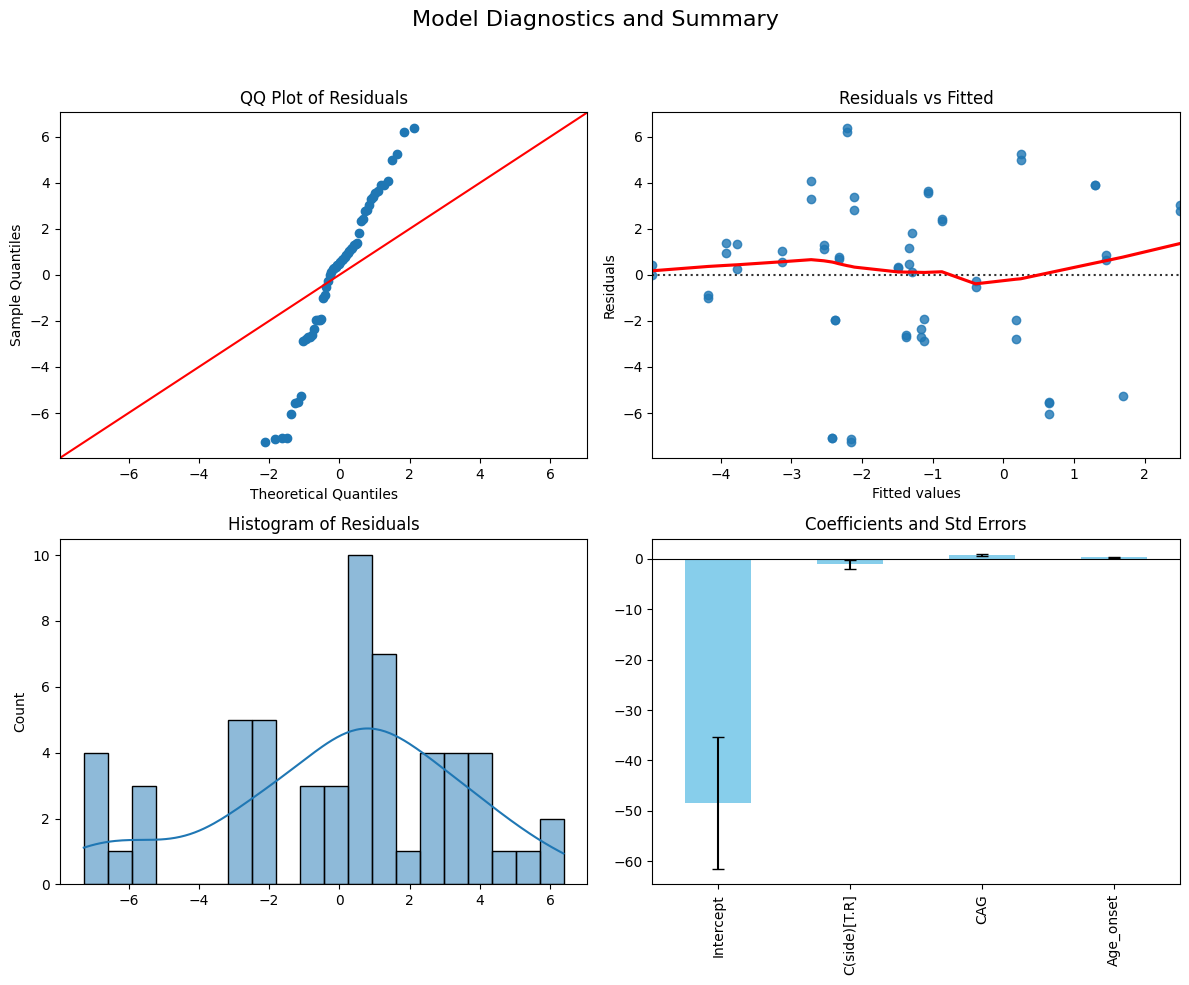

In [42]:
df = combined_CAG_only_SCA_centered
model = smf.ols(formula='iso1 ~ CAG + Age_onset + C(side)', data=df).fit()

# --- Print summary statistics ---
print(model.summary())

# --- Set up multi-plot display ---
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Model Diagnostics and Summary', fontsize=16)

# --- QQ Plot ---
sm.qqplot(model.resid, line='45', ax=axs[0, 0])
axs[0, 0].set_title('QQ Plot of Residuals')

# --- Residuals vs. Fitted ---
sns.residplot(x=model.fittedvalues, y=model.resid, lowess=True, ax=axs[0, 1],
              line_kws={'color': 'red'})
axs[0, 1].set_title('Residuals vs Fitted')
axs[0, 1].set_xlabel('Fitted values')
axs[0, 1].set_ylabel('Residuals')

# --- Histogram of Residuals ---
sns.histplot(model.resid, bins=20, kde=True, ax=axs[1, 0])
axs[1, 0].set_title('Histogram of Residuals')

# --- Coefficients bar plot ---
coefs = model.params
errors = model.bse
coefs.plot(kind='bar', yerr=errors, ax=axs[1, 1], color='skyblue', capsize=4)
axs[1, 1].set_title('Coefficients and Std Errors')
axs[1, 1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
#########################   Plotting taking into account the residuals   ##########################
# Use linear regression with Pearson's coef between residuals

curMeasure = 'iso1'
curCorVal = 'CAG'
#partialCorCol = ['Age', 'Sex','side']            
#partialCorParam =  'Age + Sex + side'              
partialCorCol = ['Age', 'Age_onset','side']            # if SCA1, SCA3
partialCorParam =  'Age + Age_onset + side'              # if SCA1, SCA3
#partialCorCol = ['Age', 'Sex', 'Age_onset','side']            # if SCA1, SCA3
#partialCorParam =  'Age + Sex + Age_onset + side'              # if SCA1, SCA3
#partialCorCol = ['Age', 'Sex', 'Age_onset','side','Disease_duration']            # if SCA1, SCA3
#partialCorParam =  'Age + Sex + Age_onset + side + Disease_duration'              # if SCA1, SCA3
#partialCorCol = ['Age', 'Sex', 'Age_onset','side','CodeICM']  # if SCA2, SCA7
#partialCorParam =  'Age + Sex + Age_onset + side + CodeICM'    # if SCA2, SCA7

# Define mapping of curCorVal to DataFrame
data_map = {
    'INAS': combined_INAS_only_SCA,
    'CAG': combined_CAG_only_SCA,
    'CCFS': combined_CCFS_only_SCA,
    'SARA': combined_only_SCA
}
curData = data_map.get(curCorVal, None)
# Optional: Raise an error or provide a message if curCorVal is invalid
if curData is None:
    print(f"Warning: No data found for curCorVal = '{curCorVal}'")
    
# Prepare the data
df = curData[[curMeasure, curCorVal] + partialCorCol] # Ensure required columns are present

################  negate the slope, optional  ################
# for matching visual direction with another figure if needed
df[curCorVal] = -df[curCorVal]
##############################################################

# Fit the OLS model using smf.ols with missing='drop'
model = smf.ols(formula=curMeasure+' ~ '+ curCorVal +' + ' + partialCorParam, data=df, missing='drop').fit()

# Partial regression: calculate residuals
residual_x = smf.ols(formula=curMeasure+' ~ '+partialCorParam, data=df, missing='drop').fit().resid
# Residual of curCorVal regressed
residual_y = smf.ols(formula=curCorVal+' ~ '+partialCorParam, data=df, missing='drop').fit().resid
raw_y = df[curCorVal]

# Align indices to ensure lengths match
residual_x, raw_y = residual_x.align(raw_y, join='inner')

## Plot the residuals
plt.figure(figsize=(10, 6))

#sns.regplot(x=residual_x, y=raw_y, scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'}) # plot y raw CAG

# if emphasize effect of CAG on shape
sns.regplot(x=residual_y, y=residual_x, scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'}) 
plt.ylabel('Residual '+curMeasure)      # plot x_CAG, y_shape
plt.xlabel('Residual '+curCorVal) 

# if emphasize effect of shape on CAG
#sns.regplot(x=residual_x, y=residual_y, scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'}) 
#plt.ylabel('Residual '+curCorVal)      # plot x_shape, y_CAG
#plt.xlabel('Residual '+curMeasure) 

plt.title('Partial Regression Plot: '+curMeasure+' ~ '+curCorVal+' (controlling for '+partialCorParam+')')
plt.grid()

################################################################################
#################  optional, add p-val and R-squared as text  ##################
"""
# Get p-value and R-squared
p_value = model.pvalues[curCorVal]
r_squared = model.rsquared

# Format the annotation string
annotation = f"$R^2$ = {r_squared:.3f}\n$p$ = {p_value:.3g}"

# Add the annotation to the plot (adjust x/y values as needed)
plt.text(
    0.05, 0.95, annotation,
    transform=plt.gca().transAxes,   # so (0.05, 0.95) is in axes fraction
    verticalalignment='top',
    horizontalalignment='left',
    fontsize=12,
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
)
"""
#################  as above, move the text box from left top to right top  #################
# Get current axis limits
xlim = plt.xlim()
ylim = plt.ylim()

# Position text box in top-right
text_x = xlim[1] - (xlim[1] - xlim[0]) * 0.35
text_y = ylim[1] - (ylim[1] - ylim[0]) * 0.1

# Annotate with R² and p-value
plt.text(
    text_x,
    text_y,
    f"$R^2$ = {r_squared:.3f}\n$p$ = {p_value:.3g}",
    fontsize=12,
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4')
)

plt.grid()
plt.tight_layout()
#############################################################################################

#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots_dec_2024\cor_SCA1_ctl_min_U14_CAG_time2_corAgeSexDurationOnset.png')
#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots_CSpreCS\cor_SCA1_ctl_max_U11_SARA_corAgeSexDurationOnsetSide.png')
#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots_CSSyl\cor_SCA1_ctl_minIso1_SARA_time1_5cofactors.png')
#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots_CSSyl\cor_SCA1_ctl_minIso3_CAG_time1_4cofactors.png')
#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots_CSSyl\cor_SCA1_ctl_maxIso1_SARA_time1_4cofactors.png')
#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots_CSSyl\cor_SCA1_ctl_minU14_CAG_time1_4cofactors.png')
#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots_CSSyl\cor_SCA2_ctl_minU23_CAG_time1_4cofactors.png')
#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\cor_SCA1_ctl_maxIso1_CAG_time1_2_ageOnsetAgeSide_neg.png')



plt.show()

In [ ]:
###################  Reverify stats of the above plot  ####################
curMeasure = 'iso1'
curCorVal = 'CAG'
#partialCorCol = ['Age', 'Sex','side']            
#partialCorParam =  'Age + Sex + side'              
partialCorCol = ['Age', 'Age_onset','side']            # if SCA1, SCA3
partialCorParam =  'Age + Age_onset + side'              # if SCA1, SCA3

model = smf.ols(formula=curMeasure+' ~ '+ curCorVal +' + ' + partialCorParam, data=df, missing='drop').fit()
print(model.summary())

In [ ]:
residual_x

In [ ]:
################  plotting only the shape to SARA correlation for SCA  ################
typeSCA = curSCA
curMeasure = 'iso3' #'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4'
corMeasure = 'CAG'

# Set the color palette
sns.set(style="white", palette="muted")
# Create the scatterplot with hue for 'SCA' column
sns.scatterplot(x=curMeasure, y=corMeasure, hue='SCA', 
                palette={typeSCA: 'red', 0: 'green'}, data=combined_CAG)
# Add the regression line for the entire dataset
#sns.regplot(x=curMeasure, y=corMeasure, data=combined_ctl_1_max, scatter=False)
# Add the regression line for SCA1 in the dataset only
sns.regplot(x=curMeasure, y=corMeasure, data=combined_CAG_only_SCA, scatter=False)

#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots_dec_2024\cor_SCA1_ctl_1_max_U14_SARA.png')
#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots_CSpreCS\cor_SCA2_ctl_max_U11_SARA.png')

plt.show()


In [ ]:
################  plotting only the shape to SARA correlation for SCA  ################
typeSCA = curSCA
curMeasure = 'iso1' #'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4'
corMeasure = 'CAG'

# Set the color palette
sns.set(style="white", palette="muted")
# Create the scatterplot with hue for 'SCA' column
sns.scatterplot(x=curMeasure, y=corMeasure, hue='Time_point', 
                palette={1: 'red', 2: 'green',3: 'blue'}, data=combined_CAG_only_SCA)
# Add the regression line for the entire dataset
#sns.regplot(x=curMeasure, y=corMeasure, data=combined_ctl_1_max, scatter=False)
# Add the regression line for SCA1 in the dataset only
sns.regplot(x=curMeasure, y=corMeasure, data=combined_CAG_only_SCA, scatter=False)

#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots_dec_2024\cor_SCA1_ctl_1_max_U14_SARA.png')
#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots_CSpreCS\cor_SCA2_ctl_max_U11_SARA.png')

plt.show()
